# 분할정복기법
- 문제를 작은 하위 문제로 나누고(분할) 각각을 해결(정복)한 뒤, 그 결과를 결합(통합)하여 원래 문제를 해결하는 알고리즘 기법
- 분할 + 정복 + 통합
- 분할 정복 기법의 예시
  - 가짜 동전 찾기
    - n 개의 동전들 중에 가짜 동전이 하나 포함되어 있다. 가짜 동전은 진짜 동전에 비해 아주 조금 가볍다. 진짜 동전들의 무게가 동일하다고 할 때 양팔 저울을 이용해서 가짜 동전을 찾아보자.
  - 거듭 제곱
    - 분할 정복 기법을 이해하기 위해, 자연수 C의 n 제곱 값을 구하는 함수를 구현해보자.

거듭 제곱 구현하기

In [18]:
def recursive_power(x, n):

    # 종료 조건
    if n == 1:
        return x

    # 짝수
    if n % 2 == 0:
        y = recursive_power(x,n//2)
        result = y**2
        return result

    # 홀수
    else:
        y = recursive_power(x,n//2)
        result = y**2 * x
        return result

print(recursive_power(3,3))

27


# 병합정렬
- 여러 개의 정렬된 자료의 집합을 병합하여 한 개의 정렬된 집합으로 만드는 방식
- 병합 정렬 과정
  - 자료를 최소 단위의 문제까지 나눈 후에 차례대로 정렬하여 최종 결과를 얻어냄
  - top - down 방식
- 시간 복잡도
  - O(n log(n))
- 병합 정렬 과정 예시
  - {69,10,30,2,16,8,31,22}를 병합 정렬하는 과정
  - 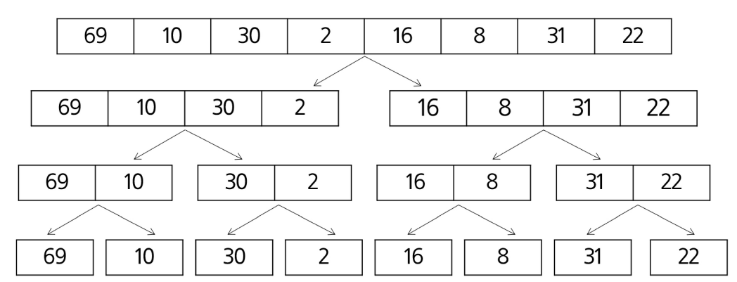
  - 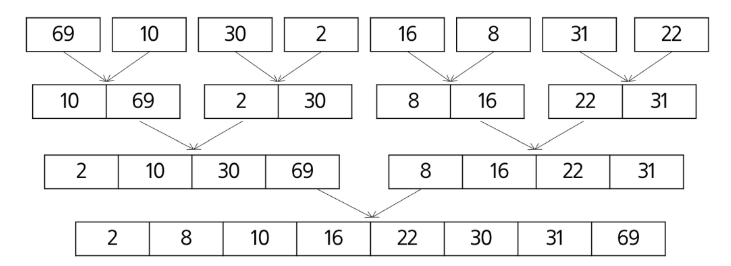

In [ ]:

# 2. 병합하는 과정 (이때, 정렬하면서 병합)
# - 왼쪽, 오른쪽 리스트 중 작은 원소부터 정답 리스트에 추가하자

def merge(left, right):
    # left[l] = 왼쪽리스트의 최솟값
    # right[r] = 오른쪽리스트의 최솟값
    # result[l+r] = result에 다음 넣을자리.
    # 두 리스트를 합한 크기만큼 나온다
    result = [0] * (len(left) + len(right))
    l = r = 0    
    # 두 리스트에서 비교할 대상이 남을 때 까지 반복
    while l < len(left) and r < len(right):
        # 왼쪽이 더 작으면 왼쪽걸 붙여라
        if left[l] < right[r]:
            result[l+r] = left[l]
            l += 1
        # 오른쪽이 더 작으면 오른쪽걸 붙여라
        else:
            result[l+r] = right[r]
            r += 1
    # 남은 데이터들을 모두 result 에 추가
    if l < len(left):
        result[l+r] = left[l]
    if r < len(right):
        result[l+r] = right[r]
    

    return result


# 1. 분할하는 과정
# - depth: 리스트의 길이가 1이 되면 끝
# - branch: 왼쪽과 오른쪽으로 리스트를 분할 (2개)
# 들어가면서 분할, 되돌아오면서 병합
def merge_sort(li):
    # 1. 종료조건
    if len(li) == 1:
        return li
    # 2. 재귀호출
    mid_index = len(li)//2
    left = li[:mid_index]
    right = li[mid_index:]
    # 하나의 리스트가 좌우 두개의 리스트를 호출한다.
    modified_left = merge_sort(left)    # 왼쪽자식의 리턴값
    modified_right = merge_sort(right)  # 오른쪽자식의 리턴값
    merge_list = merge(modified_left,modified_right) # 두개를 병합한 것이
    return merge_list                                # 자기 자신의 리턴값


arr = [69, 10, 30, 2, 16, 8, 31, 22]
sorted_arr = merge_sort(arr)
print(sorted_arr)

[2, 8, 10, 16, 22, 0, 30, 0]


# 퀵 정렬
- 기준값을 중심으로 주어진 배열을 두 개로 분할하고, 각각을 정렬하여 전체 배열을 정렬하는 방식
- 기준 아이템(pivot item)을 중심으로 기준보다 작은 것을 왼편, 큰 것을 오른편에 위치시킴.
- 별도의 병합 과정 불필요
- 평균 시간복잡도 O(n log(n))
- Partioning 이라는 과정을 반복하면서, 빠른 속도로 정렬이 되는 알고리즘.
- Partioning
  - 1. 작업 영역을 정한다.
  - 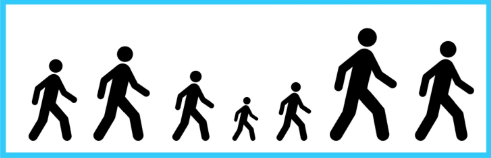
  - 2. 작업 영역 중 가장 왼쪽에 있는 수를 Pivot이라고 하자.(Pivot을 "기준"으로 해석한다.)
  - 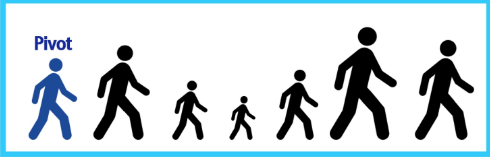
  - 3. Pivot을 기준으로
    - 왼쪽에는 Pivot 보다 작은 수를 배치한다. (정렬 안됨)
    - 오른쪽에는 Pivot 보다 큰 수를 배치한다. (정렬 안됨)
    - 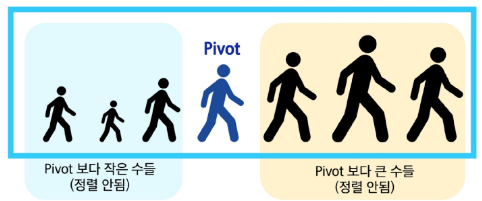
  - 파니셔닝이 끝나고 Pivot의 위치는 확정(Fix)됩니다.
  - 즉, 정렬이 다 되었을 때에도 Pivot의 위치는 지금 위치 그대로 배정됩니다.
  - 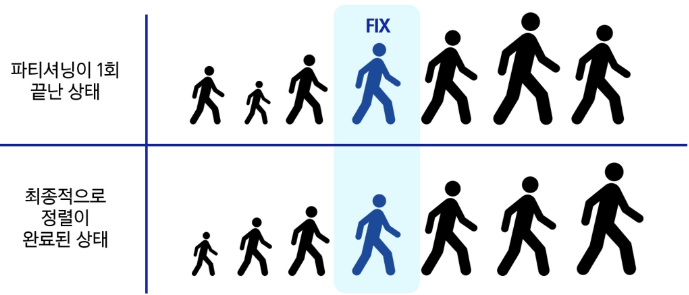
  - 한 번의 파티셔닝 이후, 왼쪽과 오른쪽 부분 배열에 대해 재귀적으로 파티셔닝을 반복하여 정렬을 진행합니다.


2. quick_sort_hoare.py

In [4]:
arr = [3, 2, 4, 6, 9, 1, 8, 7, 5]

def hoare_partition1(left,right):
    pivot = arr[left]   # 피벗을 제일 왼쪽 요소로 설정
    i = left + 1
    j = right

    while i <= j:   # 교차가 되면 끝
        while i <= j and arr[i] <= pivot: # i는 pivot 보다 큰 값을 검색 (작거나 같으면 i+=1)
            i += 1

        while i <= j and arr[j] >= pivot: # j는 pivot 보다 작은 값을 검색 (크거나 같으면 j-= 1)
            j -= 1

        if i < j:   #swap
            arr[i], arr[j] = arr[j], arr[i]

    # pivot 과 j 위치를 swap
    arr[left], arr[j] = arr[j], arr[left]
    return j  

def quick_sort(left,right):
    if left < right:
        pivot = hoare_partition1(left,right)    #pivot: fix된 pivot의 index
        quick_sort(left, pivot - 1)
        quick_sort(pivot + 1, right)


quick_sort(0, len(arr)-1)
print(arr)

[1, 2, 3, 4, 5, 6, 7, 8, 9]


이진검색 3.binary_search.py

In [ ]:
arr = [7, 4, 2, 9, 11, 23, 19]

# [주의!] 이진 검색은 항상 정렬된 데이터에 적용
arr.sort()  # 2, 4, 7, 9, 11, 19, 23

def binary_search_while(target):
    left = 0
    right = len(arr) - 1
    cnt = 0

    # 교차가 되는 순간이 탐색 못한 순간
    while left <= right:
        mid = (left + right) // 2
        cnt += 1

        # 정답을 찾으면 종료
        if arr[mid] == target:
            return mid, cnt
        
        # arr[mid] 가 target 보다 더 큰 경우 ( target 이 왼쪽에 위치)
        # - 왼쪽을 탐색
        if target < arr[mid]:
            right = mid - 1
        # arr[mid] 가 target 보다 작은 경우 (target 이 오른쪽에 위치)
        else:
            left = mid + 1
        
    return -1, cnt

targets = [9, 2, 20]
for target in targets:
    result = binary_search_while(target)
    if result[0] == -1:
        print(f"{target}은 배열에 없습니다.")
    else:
        print(f"{target}은 {result[0]}번 인덱스에 있습니다. {result[1]}번만에 찾았습니다.")




9은 3번 인덱스에 있습니다. 1번만에 찾았습니다.
2은 0번 인덱스에 있습니다. 3번만에 찾았습니다.
20은 배열에 없습니다.


In [ ]:
arr = [7, 4, 2, 9, 11, 23, 19]

# [주의!] 이진 검색은 항상 정렬된 데이터에 적용
arr.sort()  # 2, 4, 7, 9, 11, 19, 23

def binary_search_recur(left,right,target):
    # left,right 를 작업 영역으로 검색
    # left <= right 만족하면 반복
    if left > right:
        return -1
    
    mid = (left + right) // 2
    # 검색하면 종료
    if target == arr[mid]:
        return mid
    
    # 한 번 할 때마다 left와 right를 mid 기준으로 이동시켜 주면서 진행
    # 왼쪽을 봐야한다.
    if target < arr[mid]:
        return binary_search_recur(left, mid - 1, target)
    # 오른쪽을 봐야한다.
    else:
        return binary_search_recur(mid + 1, right, target)